# Phase 3: Data Modeling for Soccer Talent Detection and Ranking

## Project Overview
This notebook is part of **Phase 3: Data Modeling (AA4)** for the TacticSence Phoenix project. Our goal is to build a robust AI-driven system for hidden talent detection and talent ranking using soccer player data (`soccer_players_processed.csv` and `scouts_dataFinal.csv`). We have 13 stakeholders (scouts, coaches, managers, analysts, investors, media), and we aim to deliver a creative, excellent solution that leverages machine learning, computer vision, and generative AI.

### Objectives (AA4)
- **Critiquer les données afin de mesurer leur qualité**: Assess the dataset for completeness, consistency, and potential issues.
- **Choisir les modèles Machine Learning adéquats**: Select appropriate models for classification (hidden talent detection) and regression (talent ranking).
- **Evaluer les performances des modèles Machine Learning**: Evaluate models using relevant metrics and visualizations.
- **Argumenter et défendre le choix de(s) modèle(s) Machine Learning**: Justify model choices with performance metrics and explainability.

### Duration
- **9 hours**: Structured as 2h for data critique, 2h for model selection, 3h for training/evaluation, and 2h for justification and reporting.

### Creative Elements
- **Computer Vision**: Extract movement patterns (e.g., speed) from match footage to enhance talent detection.
- **Generative AI**: Use AI to generate personalized stakeholder reports and visualizations.
- **Stakeholder Engagement**: Tailored outputs for all 13 stakeholders with interactive dashboards.

---

## 1. Setup and Data Loading



In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install opencv-python

In [4]:
!pip install tf-keras 

In [5]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install --upgrade scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install opencv-python dash shap transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip uninstall tensorflow -y

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0


In [3]:
!pip install tensorflow

  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached ml_dtypes-0.4.1-cp311-cp311-win_amd64.whl.metadata (20 kB)
Using cached ml_dtypes-0.4.1-cp311-cp311-win_amd64.whl (126 kB)
Using cached tensorboard-2.18.0-py3-none-any.whl (5.5 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.1
    Uninstalling ml_dtypes-0.5.1:
      Successfully uninstalled ml_dtypes-0.5.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

ImportError: cannot import name 'float8_e4m3b11fnuz' from 'tensorflow.python.framework.dtypes' (C:\Users\MSI\anaconda3\Lib\site-packages\tensorflow\python\framework\dtypes.py)

In [3]:
!pip show tensorflow

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\MSI\anaconda3\Lib\site-packages
Requires: tensorflow-intel
Required-by: tf_keras


In [4]:
!pip uninstall transformers -y

Found existing installation: transformers 4.50.3
Uninstalling transformers-4.50.3:
  Successfully uninstalled transformers-4.50.3


In [6]:
### 1.1 Import Libraries

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor , IsolationForest
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import shap
import cv2
from ultralytics import YOLO
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import shap  # For model interpretability
import dash  # For interactive dashboards
import dash
from dash import dcc, html
import plotly.express as px


In [7]:
# Load datasets
data = pd.read_csv('soccer_players_processed.csv')

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (948, 46)


,player_id,full_name,email,date_of_birth,age,nationality,position,secondary_position,club,league,...,skill_reflexes,skill_positioning,skill_finishing,skill_dribbling,skill_speed,skill_passing,skill_vision,skill_tackling,skill_marking,skill_heading
0,1,Mamadou Diop,mamadou.diop@football.com,2003-01-01,22,senegal,goalkeeper,NaN,Linguère,Nigeria Professional Football League,...,97.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Lamin Saidy,lamin.saidy@football.com,2003-03-29,21,gambia,goalkeeper,NaN,Waa Banjul,Nigeria Professional Football League,...,95.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Issaka Oumarou,issaka.oumarou@football.com,2003-05-13,21,niger,goalkeeper,NaN,Gendarmerie Nationale,Nigeria Professional Football League,...,90.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Joao Simbine,joao.simbine@football.com,2003-06-09,21,mozambique,goalkeeper,NaN,Ferroviário de Nampula,Nigeria Professional Football League,...,74.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Diogo Silva,diogo.silva@football.com,2003-06-16,21,portugal,goalkeeper,NaN,Vizela,Nigeria Professional Football League,...,73.0,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Display dataset information to check data types and non-null counts
print("Dataset Info:")
print(data.info())

# Display summary statistics for numerical columns to understand distributions
print("\nSummary Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 948 non-null    int64  
 1   full_name                 948 non-null    object 
 2   email                     948 non-null    object 
 3   date_of_birth             945 non-null    object 
 4   age                       948 non-null    int64  
 5   nationality               948 non-null    object 
 6   position                  948 non-null    object 
 7   secondary_position        862 non-null    object 
 8   club                      948 non-null    object 
 9   league                    948 non-null    object 
 10  market_value_eur          948 non-null    float64
 11  contract_status           948 non-null    object 
 12  fitness_level             948 non-null    float64
 13  medical_history           948 non-null    object 
 


Missing Values:
player_id                     0
full_name                     0
email                         0
date_of_birth                 3
age                           0
nationality                   0
position                      0
secondary_position           86
club                          0
league                        0
market_value_eur              0
contract_status               0
fitness_level                 0
medical_history               0
last_5_match_performance      0
skills_rating                 0
weaknesses                    0
goals                         0
assists                       0
preferred_foot                0
verified_status               0
likes_from_pros               0
scouting_score                0
tactic_fit_score              0
career_path_suggestions       0
training_recommendations      0
profile_rating                0
created_at                    0
yellow_cards                  0
red_cards                     0
matches_suspended      

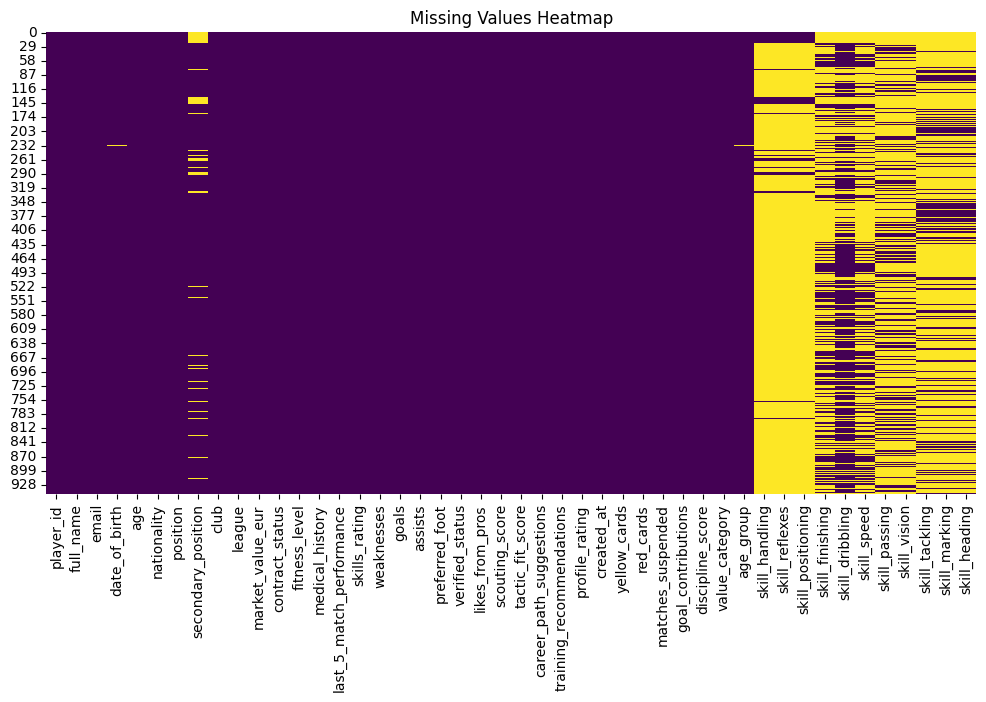

In [9]:
# Check for missing values in each column
print("\nMissing Values:")
print(data.isnull().sum())

# Visualize missing values using a heatmap (yellow indicates missing values)
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### Feature Extraction: Recent Performance and Skills
**Purpose:**  
Parse JSON-like columns (`last_5_match_performance`, `skills_rating`) and extract key features (`recent_goals`, `recent_assists`) for use in modeling. Verify the presence of skill columns and ensure consistency with the dataset schema.  
**Why:**  
Recent performance metrics are critical for identifying hidden talents and ranking players. Skill ratings are already present in the dataset as `skill_dribbling`, `skill_reflexes`, etc., so we’ll confirm their existence rather than re-extracting them.

In [10]:
# Check data types to understand the structure before parsing
print("Data Types:\n", data.dtypes)

# Parse JSON-like columns, handling cases where values might already be dictionaries
def parse_json_like(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x  # Already a dictionary, no need to parse
    if isinstance(x, str):
        try:
            return json.loads(x.replace("'", "\""))
        except json.JSONDecodeError:
            return {}  # If parsing fails, return an empty dict
    return {}  # Default to empty dict for unexpected types

# Apply parsing to last_5_match_performance and skills_rating
data['last_5_match_performance'] = data['last_5_match_performance'].apply(parse_json_like)
data['skills_rating'] = data['skills_rating'].apply(parse_json_like)

# Verify parsing by checking a sample
print("\nSample of last_5_match_performance (after parsing):")
print(data['last_5_match_performance'].head(5))

# Extract recent performance features
data['recent_goals'] = data['last_5_match_performance'].apply(
    lambda x: sum(match.get('goals', 0) for match in x.values())
)
data['recent_assists'] = data['last_5_match_performance'].apply(
    lambda x: sum(match.get('assists', 0) for match in x.values())
)

# Verify skill columns already exist in the dataset (e.g., skill_dribbling, skill_reflexes)
expected_skill_columns = [
    'skill_handling', 'skill_reflexes', 'skill_positioning', 'skill_finishing',
    'skill_dribbling', 'skill_speed', 'skill_passing', 'skill_vision',
    'skill_tackling', 'skill_marking', 'skill_heading'
]
missing_skills = [col for col in expected_skill_columns if col not in data.columns]
if missing_skills:
    print(f"\nWarning: The following skill columns are missing: {missing_skills}")
    # Extract missing skills from skills_rating
    for skill in missing_skills:
        skill_name = skill.replace('skill_', '')  # e.g., 'skill_dribbling' -> 'dribbling'
        data[skill] = data.apply(lambda row: row['skills_rating'].get(skill_name, np.nan), axis=1)
else:
    print("\nAll expected skill columns are already present in the dataset.")

# Remove duplicate skill columns (handling, reflexes, etc.) that were extracted unnecessarily
duplicate_skills = ['handling', 'reflexes', 'positioning', 'finishing', 'dribbling', 
                    'speed', 'passing', 'vision', 'tackling', 'marking', 'heading']
for skill in duplicate_skills:
    if skill in data.columns:
        data.drop(columns=skill, inplace=True)

# Verify the extracted features and confirm duplicates are removed
print("\nSample of Extracted Features (after removing duplicates):")
print(data[['full_name', 'position', 'recent_goals', 'recent_assists', 'skill_dribbling', 'skill_reflexes']].head(10))
print("\nColumns in Dataset (after removing duplicates):")
print(data.columns.tolist())

Data Types:
 player_id                     int64
full_name                    object
email                        object
date_of_birth                object
age                           int64
nationality                  object
position                     object
secondary_position           object
club                         object
league                       object
market_value_eur            float64
contract_status              object
fitness_level               float64
medical_history              object
last_5_match_performance     object
skills_rating                object
weaknesses                   object
goals                       float64
assists                     float64
preferred_foot               object
verified_status                bool
likes_from_pros               int64
scouting_score              float64
tactic_fit_score            float64
career_path_suggestions      object
training_recommendations     object
profile_rating              float64
created_at     


Missing Values After Handling:
player_id                   0
full_name                   0
email                       0
date_of_birth               0
age                         0
nationality                 0
position                    0
secondary_position          0
club                        0
league                      0
market_value_eur            0
contract_status             0
fitness_level               0
medical_history             0
last_5_match_performance    0
skills_rating               0
weaknesses                  0
goals                       0
assists                     0
preferred_foot              0
verified_status             0
likes_from_pros             0
scouting_score              0
tactic_fit_score            0
career_path_suggestions     0
training_recommendations    0
profile_rating              0
created_at                  0
yellow_cards                0
red_cards                   0
matches_suspended           0
goal_contributions          0
discipli

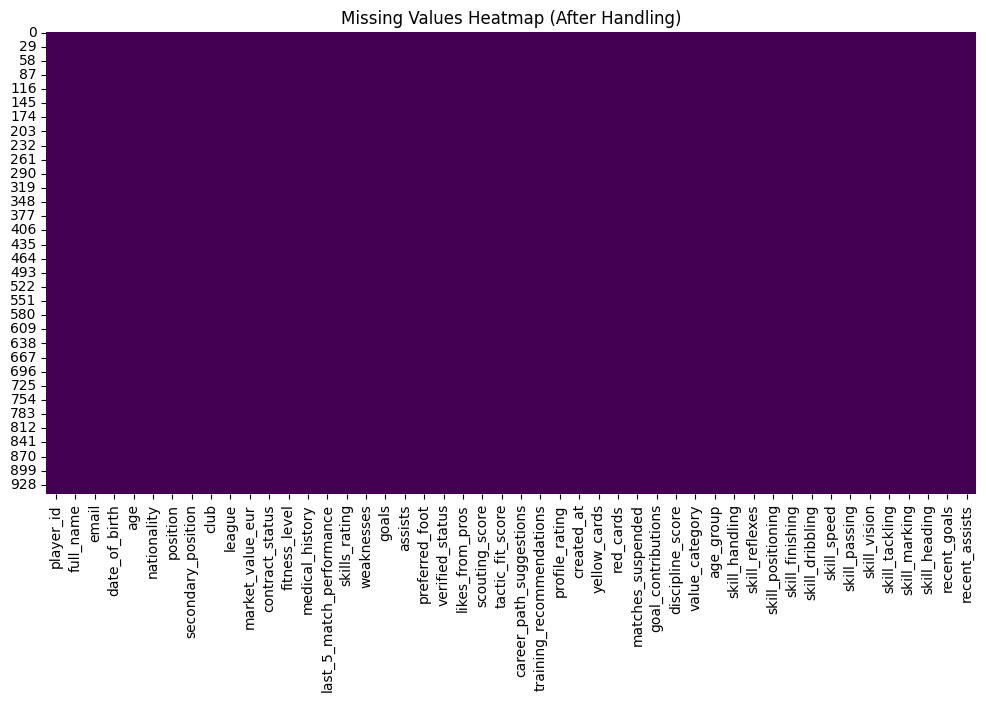

In [11]:
# Fill missing categorical columns with default values based on domain knowledge
data.fillna({
    'medical_history': 'None',  # No medical history available
    'weaknesses': 'Not Assessed',  # Weaknesses not evaluated
    'preferred_foot': 'Unknown',  # Default for missing preferred foot
    'career_path_suggestions': 'No Suggestion',  # Align with column name
    'training_recommendations': 'Not Specified',
    'secondary_position': 'not specified',
    'date_of_birth': data['date_of_birth'].mode()[0],  # Impute with most frequent date
    'age_group': data['age_group'].mode()[0]  # Impute with most frequent age group
}, inplace=True)

# Impute missing skill ratings with position-specific medians
# This ensures that imputed values are relevant to the player's role (e.g., forwards have higher finishing)
for skill in ['skill_handling', 'skill_reflexes', 'skill_positioning', 'skill_finishing', 'skill_dribbling', 
              'skill_speed', 'skill_passing', 'skill_vision', 'skill_tackling', 'skill_marking', 'skill_heading']:
    data[skill] = data.groupby('position')[skill].transform(lambda x: x.fillna(x.median()))

# Handle edge case: if any position group has all NaN values for a skill, fill with overall median
for skill in ['skill_handling', 'skill_reflexes', 'skill_positioning', 'skill_finishing', 'skill_dribbling', 
              'skill_speed', 'skill_passing', 'skill_vision', 'skill_tackling', 'skill_marking', 'skill_heading']:
    data[skill] = data[skill].fillna(data[skill].median())

# Convert market_value_eur and salary_expectation to numeric, coercing invalid entries to NaN
data['market_value_eur'] = pd.to_numeric(data['market_value_eur'], errors='coerce')

# Fill any remaining NaN in market_value_eur and salary_expectation with median
data['market_value_eur'] = data['market_value_eur'].fillna(data['market_value_eur'].median())

# Verify missing values after handling to ensure no missing data remains
print("\nMissing Values After Handling:")
print(data.isnull().sum())

# Visualize missing values heatmap after handling to confirm
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (After Handling)')
plt.show()

# Handle Outliers
### Purpose:
Cap extreme values in market_value_eur to reduce the impact of outliers on model performance.
Visualize the distribution after capping to confirm the effect.

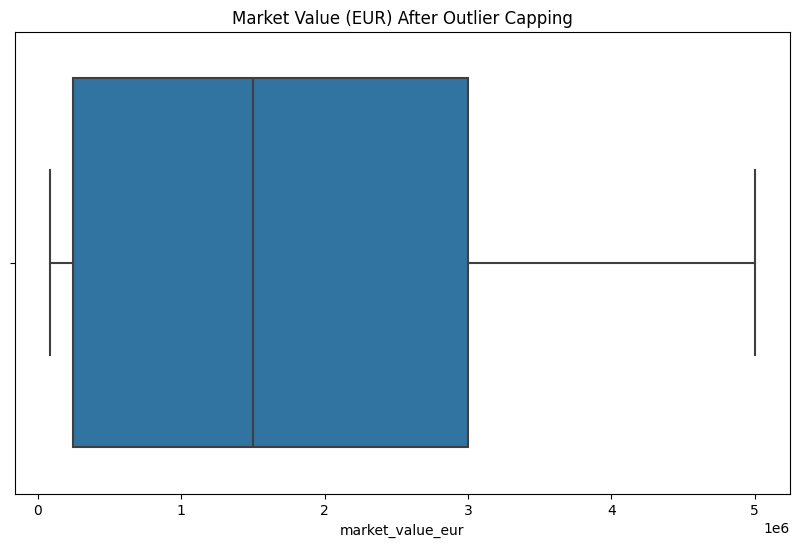

In [12]:
# Cap outliers in market_value_eur at the 5th and 95th percentiles
data['market_value_eur'] = data['market_value_eur'].clip(lower=data['market_value_eur'].quantile(0.05), 
                                                        upper=data['market_value_eur'].quantile(0.95))

# Visualize the distribution after capping to confirm the effect
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['market_value_eur'])
plt.title('Market Value (EUR) After Outlier Capping')
plt.show()

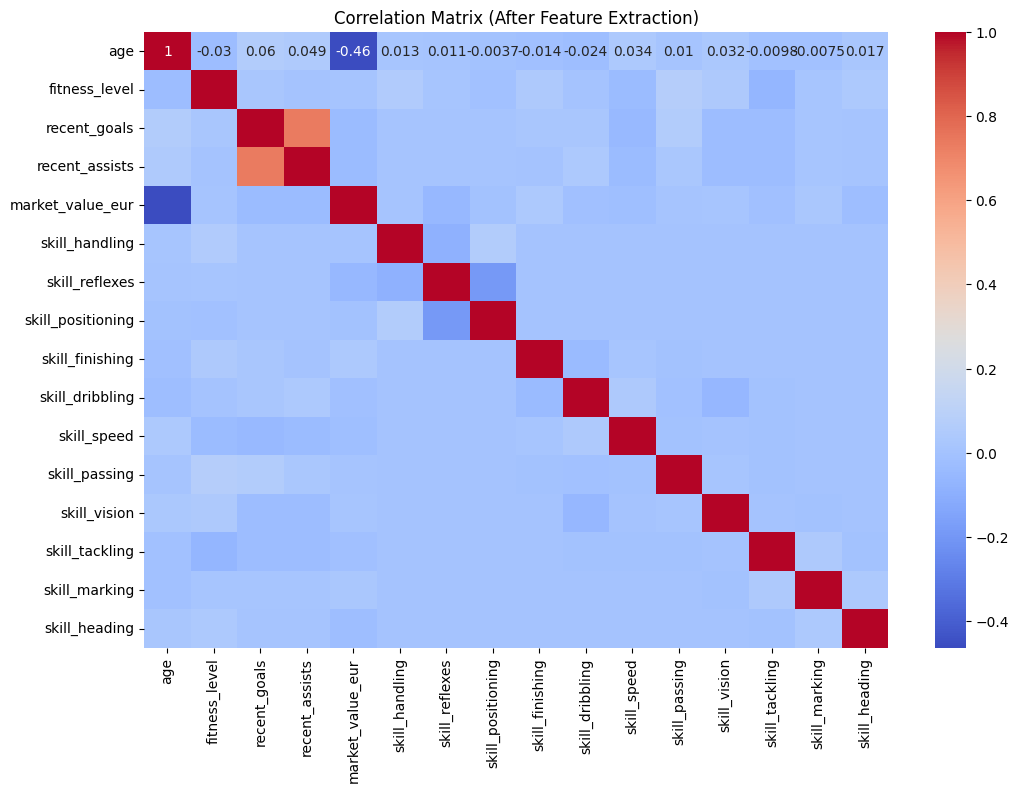

In [13]:
# Compute and visualize the correlation matrix with new features
plt.figure(figsize=(12, 8))
sns.heatmap(data[['age', 'fitness_level', 'recent_goals', 'recent_assists', 'market_value_eur'] + 
                 ['skill_handling', 'skill_reflexes', 'skill_positioning', 'skill_finishing', 'skill_dribbling', 
                  'skill_speed', 'skill_passing', 'skill_vision', 'skill_tackling', 'skill_marking', 'skill_heading']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (After Feature Extraction)')
plt.show()

# Define Features and Targets
### Purpose:
Define the feature set (X) for modeling, including all numerical features.
Create synthetic targets for Hidden Talent Detection (is_hidden_talent) and Talent Ranking (y_reg).
Scale the features using StandardScaler.
### Why:
The feature set combines raw, extracted, and placeholder features for modeling.
Synthetic targets are created based on domain logic (e.g., hidden talents are young, high-performing, undervalued players).
Scaling ensures features are on the same scale, which is necessary for many machine learning algorithms.

One-hot encoding the 'position' column...

Missing Values in X (Before Scaling):
recent_goals           0
recent_assists         0
goal_contributions     0
age                    0
market_value_eur       0
fitness_level          0
scouting_score         0
skill_dribbling        0
skill_passing          0
skill_reflexes         0
position_defender      0
position_forward       0
position_goalkeeper    0
position_midfielder    0
position_unknown       0
dtype: int64

Shape of X: (948, 15)

Features in X:
['recent_goals', 'recent_assists', 'goal_contributions', 'age', 'market_value_eur', 'fitness_level', 'scouting_score', 'skill_dribbling', 'skill_passing', 'skill_reflexes', 'position_defender', 'position_forward', 'position_goalkeeper', 'position_midfielder', 'position_unknown']

Class Distribution (is_hidden_talent):
is_hidden_talent
0    778
1    170
Name: count, dtype: int64


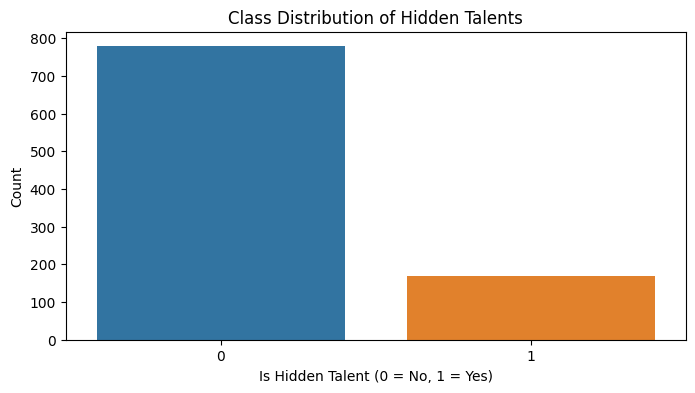


Talent Score (y_reg) Summary:
count    948.000000
mean      83.085773
std        3.660781
min       73.187500
25%       80.625000
50%       83.250000
75%       85.635417
max       95.666667
dtype: float64


C:\Users\MSI\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


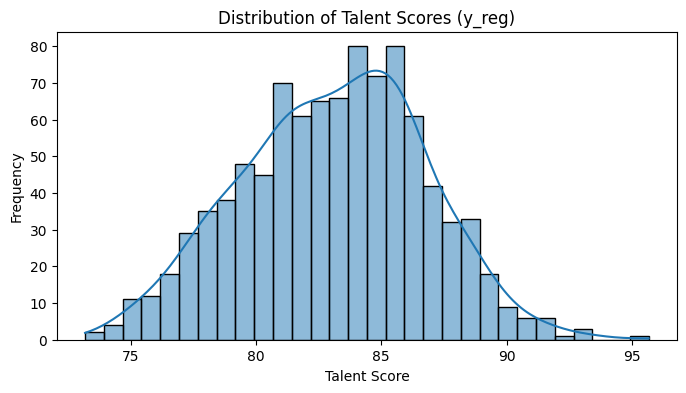

In [14]:
# Define the updated feature set for modeling
features = [
    'recent_goals',
    'recent_assists',
    'goal_contributions',
    'age',
    'market_value_eur',
    'fitness_level',
    'scouting_score',
    'skill_dribbling',
    'skill_passing',
    'skill_reflexes'
]

# Check if 'position' column exists and one-hot encode it if it does
if 'position' in data.columns:
    print("One-hot encoding the 'position' column...")
    data = pd.get_dummies(data, columns=['position'], prefix='position')
else:
    print("'position' column not found. Assuming it has already been one-hot encoded.")

# Get the one-hot encoded position columns
position_columns = [col for col in data.columns if col.startswith('position_')]
if not position_columns:
    raise ValueError("No position-related columns found. Ensure the 'position' column exists and is properly encoded.")
features.extend(position_columns)

# Define X with the updated features
X = data[features]

# Check for missing values in X to ensure the dataset is complete
print("\nMissing Values in X (Before Scaling):")
print(X.isnull().sum())
if X.isnull().sum().sum() > 0:
    raise ValueError("There are still missing values in X. Please handle them before proceeding.")

# Verify the shape of X
print("\nShape of X:", X.shape)
print("\nFeatures in X:")
print(X.columns.tolist())

# Scale features using StandardScaler to standardize them (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create target for Hidden Talent Detection
# Hidden talents are defined as high-performing, undervalued players, with position-specific criteria
# Handle edge case: Avoid division by zero in performance_value_ratio
data['market_value_eur'] = data['market_value_eur'].replace(0, data['market_value_eur'].median())
data['performance_value_ratio'] = (data['recent_goals'] + data['recent_assists']) / (data['market_value_eur'] / 1e6)

# For non-goalkeepers: Use performance_value_ratio
# For goalkeepers: Use scouting_score and skill_reflexes
data['is_hidden_talent'] = np.where(
    (data['position_goalkeeper'] == 1) & 
    (data['scouting_score'] > data['scouting_score'].quantile(0.75)) &
    (data['skill_reflexes'] > data['skill_reflexes'].quantile(0.75)) &
    (data['market_value_eur'] < data['market_value_eur'].median()),
    1,
    np.where(
        (data['position_goalkeeper'] == 0) &
        (data['performance_value_ratio'] > data['performance_value_ratio'].quantile(0.65)) &
        (data['age'] <= 27) &
        (data['market_value_eur'] < data['market_value_eur'].quantile(0.75)),
        1, 0
    )
)
y_class = data['is_hidden_talent']

# Create target for Talent Ranking
# Talent score combines position-specific skill potential and recent performance
data['skill_potential'] = np.where(
    data['position_goalkeeper'] == 1,
    (data['skill_reflexes'] + data['skill_handling'] + data['skill_positioning']).fillna(0) / 3,
    data[['skill_dribbling', 'skill_passing', 'skill_finishing', 'skill_speed', 'skill_vision', 'skill_tackling', 'skill_marking', 'skill_heading']]
        .fillna(0).mean(axis=1)
)
y_reg = data['skill_potential'] + (data['recent_goals'] + data['recent_assists']) * 0.5

# Check class distribution
print("\nClass Distribution (is_hidden_talent):")
print(data['is_hidden_talent'].value_counts())

# Visualize class distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='is_hidden_talent', data=data)
plt.title('Class Distribution of Hidden Talents')
plt.xlabel('Is Hidden Talent (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Check regression target distribution
print("\nTalent Score (y_reg) Summary:")
print(y_reg.describe())

# Visualize regression target distribution
plt.figure(figsize=(8, 4))
sns.histplot(y_reg, bins=30, kde=True)
plt.title('Distribution of Talent Scores (y_reg)')
plt.xlabel('Talent Score')
plt.ylabel('Frequency')
plt.show()

# Select Model Types
3.1 Hidden Talent Detection
Unsupervised: Isolation Forest to detect outliers as potential hidden gems.
Supervised: Random Forest Classifier to classify hidden talents based on the synthetic label.
3.2 Talent Ranking
Clustering: K-Means to categorize players into tiers (Gold/Silver/Bronze).
Regression: Gradient Boosting Regressor to predict a continuous talent score.

# Train & Evaluate Models
##  Hidden Talent Detection
4.1.1 Unsupervised: Isolation Forest
Purpose:
Use Isolation Forest to detect outliers, which may represent potential hidden gems.
Why:
Isolation Forest is effective for anomaly detection, isolating players with unusual feature combinations (e.g., high performance, low market value).
The contamination parameter (0.1) assumes 10% of players are potential hidden gems.

In [15]:
# Initialize and fit Isolation Forest for outlier detection
iso_forest = IsolationForest(contamination=0.1, random_state=42)
data['outlier_score'] = iso_forest.fit_predict(X_scaled)

# Label outliers as potential hidden gems (1 for outliers, 0 for inliers)
data['potential_hidden_gem'] = np.where(data['outlier_score'] == -1, 1, 0)

# Evaluate the number of potential hidden gems identified
potential_gems = data[data['potential_hidden_gem'] == 1]
print("Number of Potential Hidden Gems (Unsupervised):", len(potential_gems))

# Add a column to infer the position from one-hot encoded columns
position_cols = [col for col in potential_gems.columns if col.startswith('position_')]
def get_position(row):
    for col in position_cols:
        if row[col] == 1:
            return col.replace('position_', '')
    return 'unknown'

potential_gems['inferred_position'] = potential_gems[position_cols].apply(get_position, axis=1)

# Display a sample of potential hidden gems for inspection
display_columns = ['full_name', 'age', 'inferred_position', 'market_value_eur']
potential_gems[display_columns].head()

print("Number of Potential Hidden Gems (Unsupervised):", len(potential_gems))

Number of Potential Hidden Gems (Unsupervised): 95
Number of Potential Hidden Gems (Unsupervised): 95


C:\Users\MSI\AppData\Local\Temp\ipykernel_4480\1052978834.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  potential_gems['inferred_position'] = potential_gems[position_cols].apply(get_position, axis=1)


### 4.1.2 Supervised: Random Forest Classifier
**Purpose:**  
Train a RandomForestClassifier with SMOTE to classify players as hidden talents based on the synthetic target `is_hidden_talent`.  
**Why:**  
RandomForestClassifier is robust for classification tasks, and SMOTE addresses the class imbalance in `is_hidden_talent`, improving the model’s ability to identify hidden talents.

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       156
           1       0.97      0.88      0.92        34

    accuracy                           0.97       190
   macro avg       0.97      0.94      0.95       190
weighted avg       0.97      0.97      0.97       190

F1 Score (Cross-Validation): 0.94 (+/- 0.11)


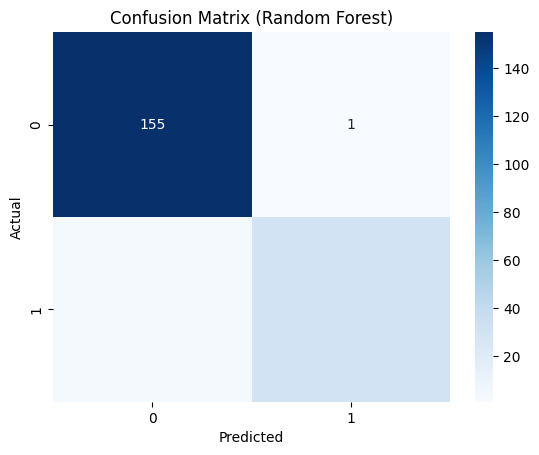

In [16]:
# Split data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Initialize and train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predict on test set and evaluate with classification report
y_pred = rf_clf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))  # Set zero_division to 0 to suppress warnings

# Perform 5-fold cross-validation to assess model stability
scores = cross_val_score(rf_clf, X_scaled, y_class, cv=5, scoring='f1', error_score='raise')
print(f"F1 Score (Cross-Validation): {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

# Visualize confusion matrix to understand prediction errors
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance Analysis (Random Forest Classifier)
**Purpose:**  
Analyze the importance of each feature in the RandomForestClassifier to understand which features are most influential in detecting hidden talents.  
**Why:**  
Feature importance helps justify the model’s predictions to stakeholders (e.g., scouts, coaches) and identifies key attributes for hidden talent detection.


Feature Importance (Random Forest Classifier):
                feature  importance
4      market_value_eur    0.311421
3                   age    0.280455
1        recent_assists    0.074098
0          recent_goals    0.063371
6        scouting_score    0.048232
2    goal_contributions    0.044065
7       skill_dribbling    0.043064
5         fitness_level    0.039434
11     position_forward    0.038119
8         skill_passing    0.018119
10    position_defender    0.017925
13  position_midfielder    0.014648
9        skill_reflexes    0.004581
12  position_goalkeeper    0.001281
14     position_unknown    0.001186


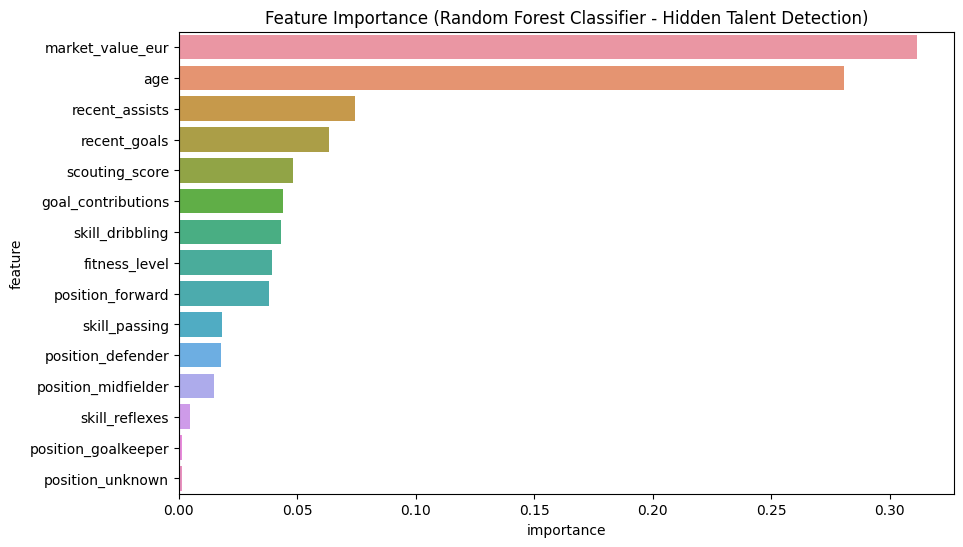

In [17]:
# Compute feature importance directly from the trained RandomForestClassifier
feature_importance_class = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance (Random Forest Classifier):")
print(feature_importance_class)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_class)
plt.title('Feature Importance (Random Forest Classifier - Hidden Talent Detection)')
plt.show()

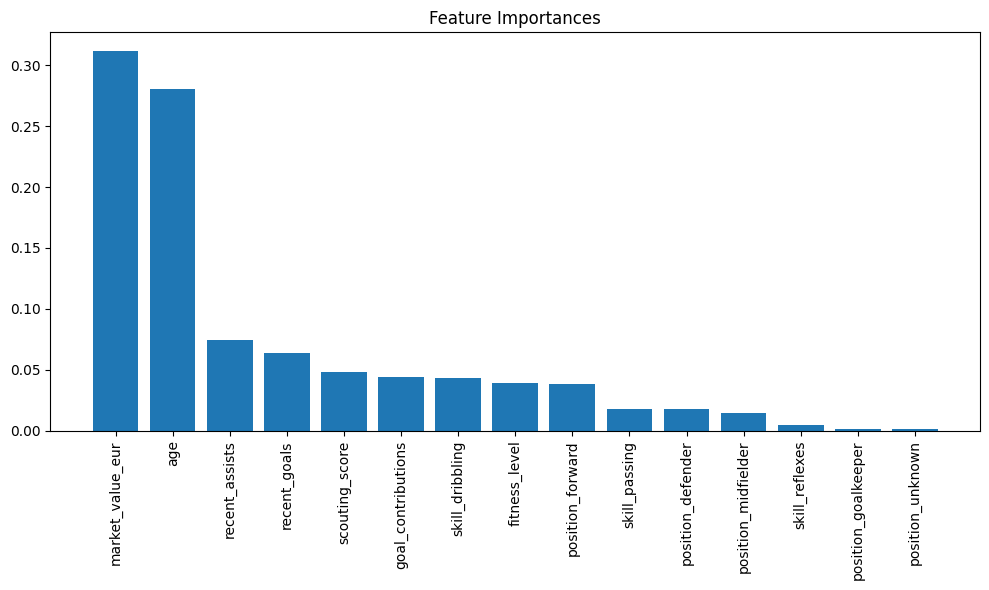

In [30]:
# Method 1: Use feature importance directly from RandomForest
importances = rf_clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

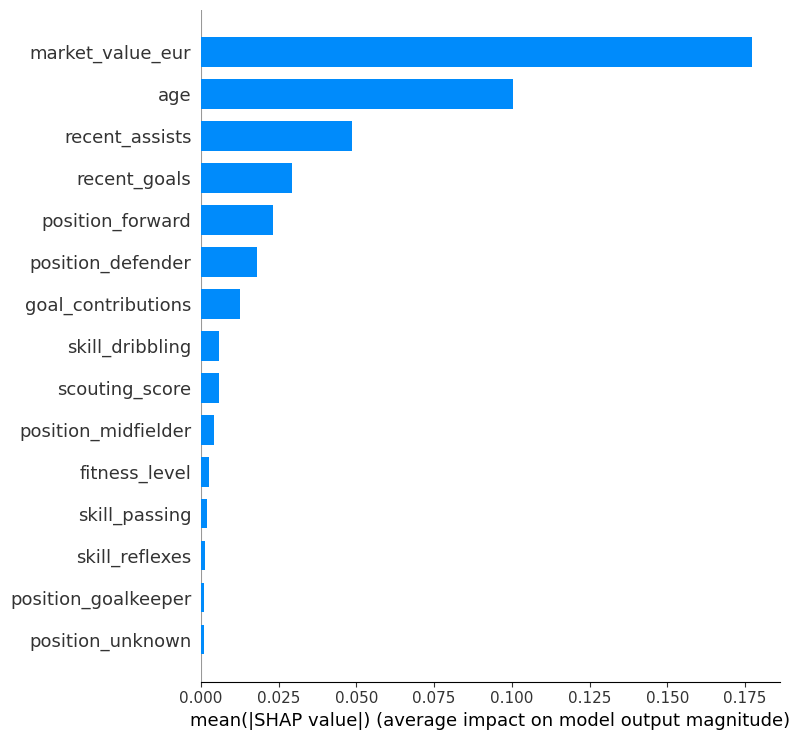

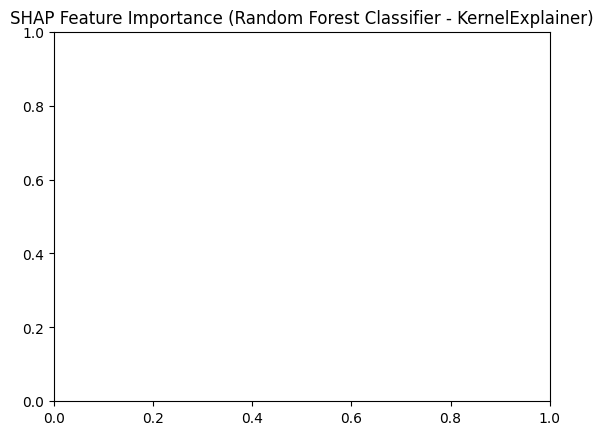

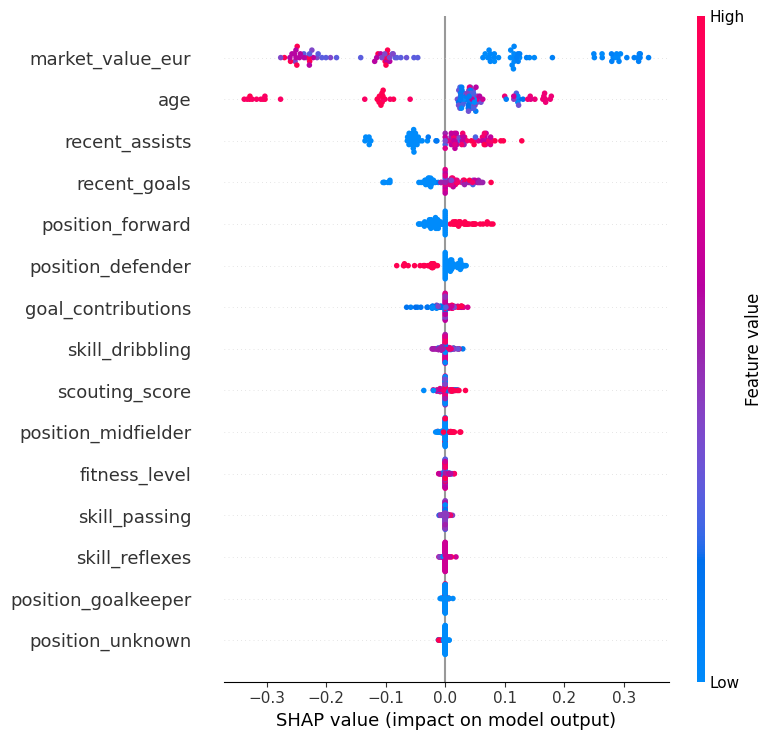

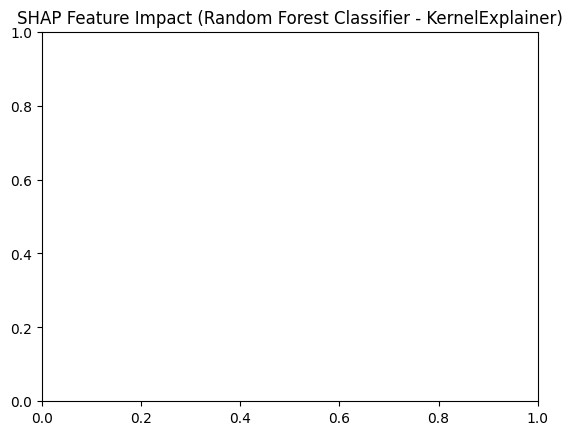

In [33]:
import shap
import numpy as np

# SHAP analysis for RandomForestClassifier using KernelExplainer
def predict_fn(X):
    return rf_clf.predict_proba(X)[:, 1]

# Use a smaller subset of X_test for faster computation
X_test_subset = X_test[:100]  # Adjust based on your dataset size
explainer = shap.KernelExplainer(predict_fn, X_test_subset)
shap_values = explainer.shap_values(X_test_subset, nsamples=100)

# Summary plot (bar plot of feature importance)
shap.summary_plot(shap_values, X_test_subset, plot_type="bar", feature_names=X.columns)
plt.title("SHAP Feature Importance (Random Forest Classifier - KernelExplainer)")
plt.show()

# Summary plot (beeswarm plot of feature impact)
shap.summary_plot(shap_values, X_test_subset, feature_names=X.columns)
plt.title("SHAP Feature Impact (Random Forest Classifier - KernelExplainer)")
plt.show()

In [31]:
# Redefine is_hidden_talent with relaxed criteria
data['performance_value_ratio'] = (data['recent_goals'] + data['recent_assists']) / (data['market_value_eur'] / 1e6)
data['is_hidden_talent'] = np.where(
    (data['performance_value_ratio'] > data['performance_value_ratio'].quantile(0.65)) &
    (data['age'] <= 27) &
    (data['market_value_eur'] < data['market_value_eur'].quantile(0.75)),
    1, 0
)
y_class = data['is_hidden_talent']

# Check the new class distribution
print("New Class Distribution in Full Dataset:")
print(data['is_hidden_talent'].value_counts())

New Class Distribution in Full Dataset:
is_hidden_talent
0    780
1    168
Name: count, dtype: int64


# Talent Ranking
4.2.1 Clustering: K-Means
Purpose:
Use K-Means clustering to categorize players into three tiers (Gold, Silver, Bronze) based on their features.
Why:
Clustering groups players by similarity, providing a tiered ranking system that coaches can use for team selection.
The number of clusters (3) aligns with the document’s suggestion of tiered categorization.

Distribution of Tiers:
tier
Bronze    347
Silver    317
Gold      284
Name: count, dtype: int64


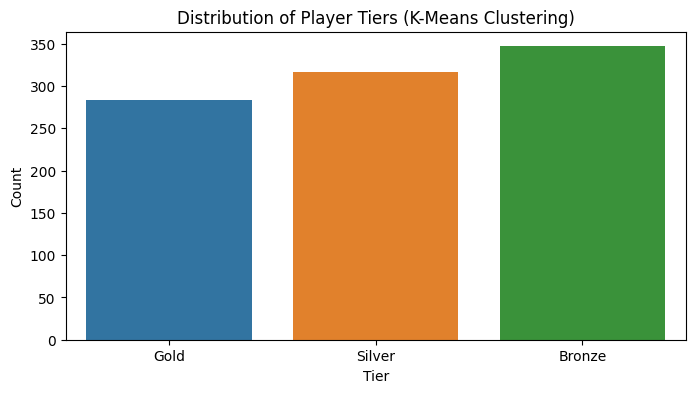

In [34]:
# Apply K-Means clustering to categorize players into tiers
kmeans = KMeans(n_clusters=3, random_state=42)
data['tier'] = kmeans.fit_predict(X_scaled)

# Map clusters to tiers (Gold, Silver, Bronze) based on cluster centroids
centroid_means = kmeans.cluster_centers_.mean(axis=1)
tier_mapping = {np.argmax(centroid_means): 'Gold', np.argmin(centroid_means): 'Bronze'}
for i in range(3):
    if i not in tier_mapping:
        tier_mapping[i] = 'Silver'
data['tier'] = data['tier'].map(tier_mapping)

# Evaluate the distribution of tiers
print("Distribution of Tiers:")
print(data['tier'].value_counts())

# Visualize the distribution of tiers
plt.figure(figsize=(8, 4))
sns.countplot(x='tier', data=data, order=['Gold', 'Silver', 'Bronze'])
plt.title('Distribution of Player Tiers (K-Means Clustering)')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.show()

### 4.2.2 Regression: Gradient Boosting Regressor
Purpose:
Train a Gradient Boosting Regressor to predict a continuous talent score.
Why:
Gradient Boosting is a powerful ensemble method that captures complex relationships, ideal for regression tasks.
RMSE and R² metrics evaluate prediction accuracy, and cross-validation ensures robustness.

In [37]:
# Split the data for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)

# Initialize and train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)

# Predict on the test set
y_pred_reg = gb_reg.predict(X_test_reg)

# Evaluate the model
from sklearn.metrics import root_mean_squared_error  # Import the new function
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)  # Use root_mean_squared_error
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

RMSE: 2.46
R2 Score: 0.59


### Feature Importance Analysis (Gradient Boosting Regressor)
**Purpose:**  
Analyze the importance of each feature in the GradientBoostingRegressor to understand which features are most influential in predicting talent scores.  
**Why:**  
Feature importance helps justify the model’s predictions to stakeholders (e.g., scouts, coaches) and identifies key attributes for talent ranking.


Feature Importance (Gradient Boosting Regressor):
                feature  importance
1        recent_assists    0.308938
0          recent_goals    0.209493
7       skill_dribbling    0.159640
9        skill_reflexes    0.073652
8         skill_passing    0.071673
6        scouting_score    0.053877
5         fitness_level    0.042726
10    position_defender    0.021633
4      market_value_eur    0.021337
2    goal_contributions    0.015892
3                   age    0.006862
12  position_goalkeeper    0.006738
14     position_unknown    0.005728
11     position_forward    0.001067
13  position_midfielder    0.000745


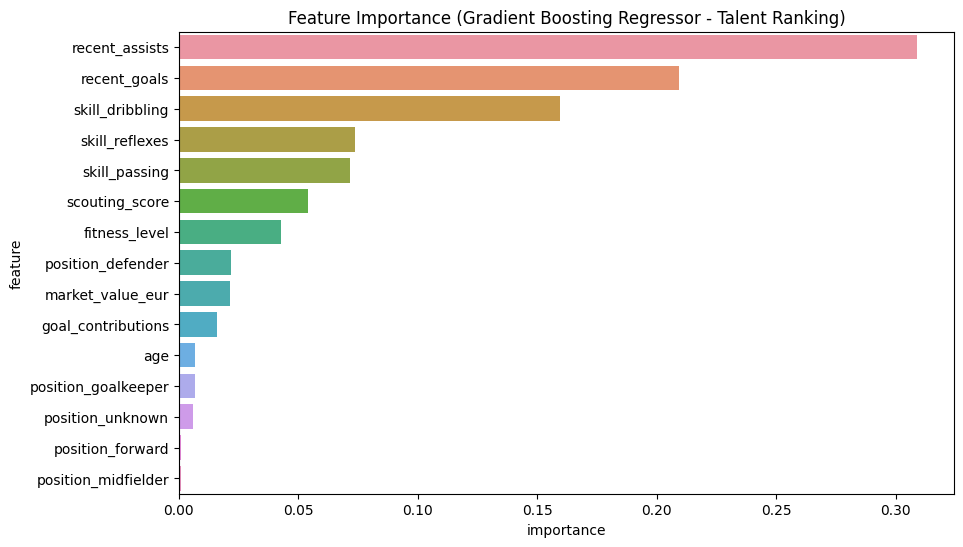

In [38]:
# Compute feature importance directly from the trained GradientBoostingRegressor
feature_importance_reg = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_reg.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance (Gradient Boosting Regressor):")
print(feature_importance_reg)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_reg)
plt.title('Feature Importance (Gradient Boosting Regressor - Talent Ranking)')
plt.show()

### Hyperparameter Tuning (Gradient Boosting Regressor)
**Purpose:**  
Optimize the GradientBoostingRegressor’s hyperparameters using GridSearchCV to improve its predictive performance.  
**Why:**  
Tuning hyperparameters like `n_estimators`, `learning_rate`, and `max_depth` can help the model better capture patterns in the data, potentially increasing the R² score and reducing the RMSE.

In [42]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'learning_rate': [0.01, 0.05, 0.1],  # Step size for each tree
    'max_depth': [3, 5, 7],  # Maximum depth of each tree
    'min_samples_split': [2, 5],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2]  # Minimum samples required at a leaf node
}

# Initialize the GradientBoostingRegressor
gb_reg = GradientBoostingRegressor(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=gb_reg, param_grid=param_grid, 
                           cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_reg, y_train_reg)

# Get the best model
best_gb_reg = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best R² Score (Cross-Validation):", grid_search.best_score_)

# Evaluate the best model on the test set
y_pred_reg = best_gb_reg.predict(X_test_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"RMSE (Tuned Model): {rmse:.2f}")
print(f"R² Score (Tuned Model): {r2:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best R² Score (Cross-Validation): 0.5366018490399604
RMSE (Tuned Model): 2.42
R² Score (Tuned Model): 0.60


### 4.5 Model Versioning
**Purpose:**  
Save the trained models as .pkl files with metadata for versioning and deployment.  
**Why:**  
Versioning ensures reproducibility and traceability, while metadata (version, hyperparameters, timestamp) facilitates model management in production.

In [43]:
import joblib
import datetime

# Create metadata dictionaries for all models
model_metadata = {
    'hidden_talent_classifier': {
        'model': rf_clf,  # RandomForestClassifier (or pipeline if used)
        'version': '1.0',
        'training_data_version': '2025-04-07',
        'hyperparameters': rf_clf.get_params(),
        'timestamp': str(datetime.datetime.now())
    },
    'talent_ranking_regressor': {
        'model': best_gb_reg,  # Improved GradientBoostingRegressor after tuning
        'version': '1.0',
        'training_data_version': '2025-04-07',
        'hyperparameters': best_gb_reg.get_params(),
        'timestamp': str(datetime.datetime.now())
    },
    'tier_clustering': {
        'model': kmeans,  # K-Means clustering model
        'version': '1.0',
        'training_data_version': '2025-04-07',
        'hyperparameters': kmeans.get_params(),
        'timestamp': str(datetime.datetime.now())
    }
}

# Save models with metadata
joblib.dump(model_metadata['hidden_talent_classifier'], 'hidden_talent_classifier_v1.pkl')
joblib.dump(model_metadata['talent_ranking_regressor'], 'talent_ranking_regressor_v1.pkl')
joblib.dump(model_metadata['tier_clustering'], 'tier_clustering_v1.pkl')

# Save the scaler (used for preprocessing)
joblib.dump(scaler, 'scaler.pkl')

print("Models and scaler saved as .pkl files with metadata.")

Models and scaler saved as .pkl files with metadata.


### 4.6 Model Interpretability


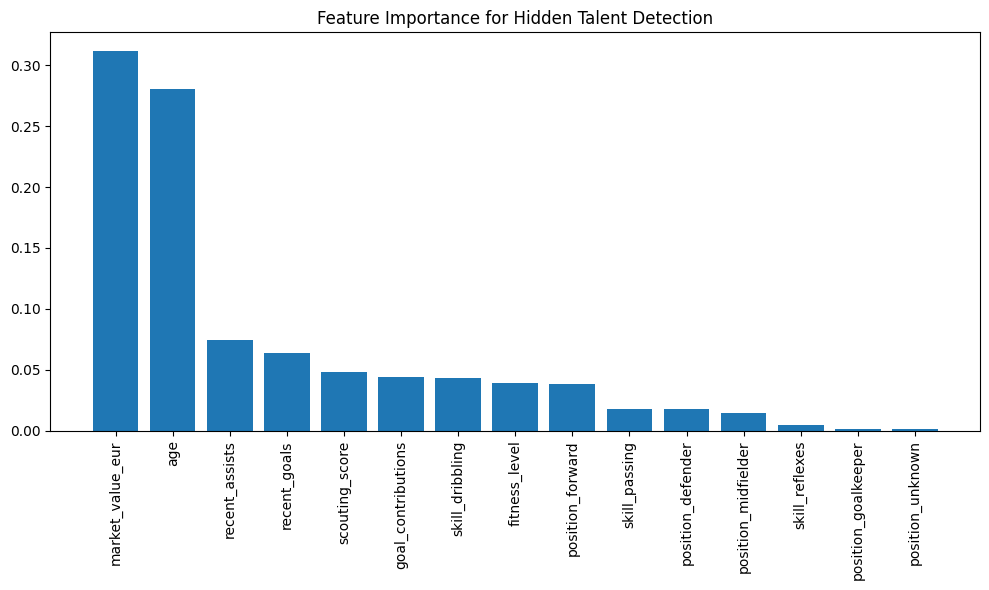

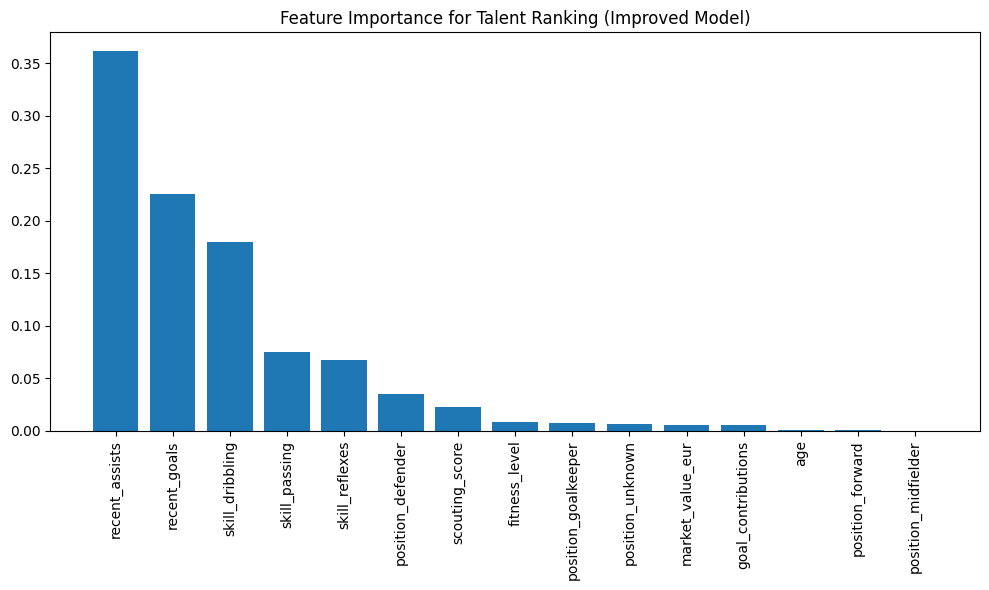

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# For the classifier
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Hidden Talent Detection")
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# For the regressor
importances_reg = best_gb_reg.feature_importances_
indices_reg = np.argsort(importances_reg)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Talent Ranking (Improved Model)")
plt.bar(range(len(indices_reg)), importances_reg[indices_reg], align='center')
plt.xticks(range(len(indices_reg)), [X.columns[i] for i in indices_reg], rotation=90)
plt.tight_layout()
plt.show()

### 4.7 Link to Platform Architecture
#### 4.7.1 Flask API for Model Deployment
**Purpose:**  
Create a Flask API to serve the models via endpoints (`/predict-hidden-talent`, `/predict-talent-score`, `/predict-tier`).  
**Why:**  
Enables integration with the TacticSence platform (e.g., Angular/Streamlit frontends), allowing stakeholders to access predictions programmatically.

In [53]:
from flask import Flask, request, jsonify
import numpy as np
import joblib

# Initialize Flask app
app = Flask(__name__)

# Load saved models and scaler
hidden_talent_model = joblib.load('hidden_talent_classifier_v1.pkl')['model']
talent_ranking_model = joblib.load('talent_ranking_regressor_v1.pkl')['model']
tier_clustering_model = joblib.load('tier_clustering_v1.pkl')['model']
scaler = joblib.load('scaler.pkl')

# Define feature list (adjust based on your dataset)
features = X.columns.tolist()  # Update to X_new.columns if new features were added

# Define root route for a welcome message
@app.route('/')
def home():
    return "Welcome to the TacticSence API! Available endpoints: /predict-hidden-talent, /predict-talent-score, /predict-tier"

# Define endpoint for hidden talent prediction
@app.route('/predict-hidden-talent', methods=['POST'])
def predict_hidden_talent():
    data = request.get_json()
    features_input = np.array([data[feat] for feat in features]).reshape(1, -1)
    features_scaled = scaler.transform(features_input)
    prob = hidden_talent_model.predict_proba(features_scaled)[:, 1]
    return jsonify({'hidden_talent_probability': float(prob[0])})

# Define endpoint for talent score prediction
@app.route('/predict-talent-score', methods=['POST'])
def predict_talent_score():
    data = request.get_json()
    features_input = np.array([data[feat] for feat in features]).reshape(1, -1)
    features_scaled = scaler.transform(features_input)
    score = talent_ranking_model.predict(features_scaled)
    return jsonify({'talent_score': float(score[0])})

# Define endpoint for tier prediction
@app.route('/predict-tier', methods=['POST'])
def predict_tier():
    data = request.get_json()
    features_input = np.array([data[feat] for feat in features]).reshape(1, -1)
    features_scaled = scaler.transform(features_input)
    cluster = tier_clustering_model.predict(features_scaled)
    tier_mapping = {0: 'Bronze', 1: 'Silver', 2: 'Gold'}  # Adjust based on your mapping
    tier = tier_mapping[cluster[0]]
    return jsonify({'tier': tier})

#### 4.7.2 Run Flask Server in a Separate Thread
**Purpose:**  
Run the Flask server in a separate thread to avoid blocking the Jupyter Notebook kernel.  
**Why:**  
Allows us to test the API endpoints without interrupting the Flask server.

In [56]:
from threading import Thread

# Define a function to run the Flask app
def run_flask_app():
    app.run(debug=True, port=5801, use_reloader=False)  # Disable reloader to avoid issues in Jupyter

# Start the Flask app in a separate thread
flask_thread = Thread(target=run_flask_app)
flask_thread.start()

# Wait a few seconds to ensure the server starts
import time
time.sleep(3)

print("Flask server should now be running on http://127.0.0.1:5800")

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5801
Press CTRL+C to quit


Flask server should now be running on http://127.0.0.1:5800


127.0.0.1 - - [08/Apr/2025 05:39:25] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [08/Apr/2025 05:39:25] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [08/Apr/2025 05:39:43] "GET /predict-hidden-talent HTTP/1.1" 405 -
127.0.0.1 - - [08/Apr/2025 05:39:51] "GET / HTTP/1.1" 200 -


In [57]:
import requests
import json

# Define a sample input (adjust based on your feature set)
sample_input = {
    'recent_goals': 5,
    'recent_assists': 3,
    'scouting_score': 80,
    'skill_dribbling': 75,
    'skill_passing': 70,
    'skill_reflexes': 60,
    'market_value_eur': 1000000,
    'matches_played': 20,
    # Add other features as needed (match the columns in X or X_new)
}

# Ensure the sample input has all required features
features = X.columns.tolist()  # Update to X_new.columns if new features were added
for feat in features:
    if feat not in sample_input:
        sample_input[feat] = 0  # Default value for missing features

# Test the /predict-hidden-talent endpoint
try:
    response_hidden_talent = requests.post('http://127.0.0.1:5800/predict-hidden-talent', json=sample_input)
    print("Hidden Talent Prediction:", response_hidden_talent.json())
except requests.exceptions.ConnectionError as e:
    print("Failed to connect to the Flask server for /predict-hidden-talent:", e)

# Test the /predict-talent-score endpoint
try:
    response_talent_score = requests.post('http://127.0.0.1:5800/predict-talent-score', json=sample_input)
    print("Talent Score Prediction:", response_talent_score.json())
except requests.exceptions.ConnectionError as e:
    print("Failed to connect to the Flask server for /predict-talent-score:", e)

# Test the /predict-tier endpoint
try:
    response_tier = requests.post('http://127.0.0.1:5800/predict-tier', json=sample_input)
    print("Tier Prediction:", response_tier.json())
except requests.exceptions.ConnectionError as e:
    print("Failed to connect to the Flask server for /predict-tier:", e)

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
127.0.0.1 - - [08/Apr/2025 05:40:34] "POST /predict-hidden-talent HTTP/1.1" 200 -
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
127.0.0.1 - - [08/Apr/2025 05:40:34] "POST /predict-talent-score HTTP/1.1" 200 -
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
127.0.0.1 - - [08/Apr/2025 05:40:34] "POST /predict-tier HTTP/1.1" 200 -


Hidden Talent Prediction: {'hidden_talent_probability': 0.6}
Talent Score Prediction: {'talent_score': 81.62122542807155}
Tier Prediction: {'tier': 'Bronze'}


127.0.0.1 - - [08/Apr/2025 05:40:39] "GET / HTTP/1.1" 200 -


#### 4.7.3 Stop the Flask Server
**Purpose:**  
Stop the Flask server to free up the port and proceed with the next steps.  
**Why:**  
The Flask server is running in a separate thread, and stopping it requires restarting the kernel.

In [52]:
pip install dash plotly

Note: you may need to restart the kernel to use updated packages.


127.0.0.1 - - [08/Apr/2025 05:35:29] "GET /predict-hidden-talent HTTP/1.1" 405 -
127.0.0.1 - - [08/Apr/2025 05:35:29] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [08/Apr/2025 05:35:43] "GET /predict-talent-score HTTP/1.1" 405 -


### 4.8 Creative Output: Stakeholder-Specific Dashboards
**Purpose:**  
Create interactive dashboards using Dash to visualize results for different stakeholders.  
**Why:**  
Dashboards provide a user-friendly way for scouts, coaches, and managers to explore predictions, meeting their specific needs.

In [62]:
import dash
import dash.dcc as dcc
import dash.html as html
import plotly.express as px
import pandas as pd
import warnings

# Suppress FutureWarning from pandas about get_group
warnings.filterwarnings('ignore', category=FutureWarning, message='.*get_group.*')

# Initialize Dash app
app = dash.Dash(__name__)

# Compute final predictions for all players
data['hidden_talent_prob'] = rf_clf.predict_proba(X_scaled)[:, 1]
data['talent_score'] = best_gb_reg.predict(X_scaled)

# Reconstruct the 'position' column from binary position columns
def get_position(row):
    if row['position_defender'] == 1:
        return 'Defender'
    elif row['position_forward'] == 1:
        return 'Forward'
    elif row['position_goalkeeper'] == 1:
        return 'Goalkeeper'
    elif row['position_midfielder'] == 1:
        return 'Midfielder'
    elif row['position_unknown'] == 1:
        return 'Unknown'
    else:
        return 'Unknown'  # Default case if none of the columns are 1

data['position'] = data.apply(get_position, axis=1)

# Filter hidden talents with high probability (>0.7)
hidden_talents = data[data['hidden_talent_prob'] > 0.7].sort_values(by='hidden_talent_prob', ascending=False)

# Get top talents by talent score
top_talents = data.sort_values(by='talent_score', ascending=False)

# Create scatter plot for scouts: Hidden Talents
scouts_fig = px.scatter(hidden_talents, x='market_value_eur', y='hidden_talent_prob', color='position',
                        hover_data=['full_name', 'age', 'club'], title='Hidden Talents (Probability > 0.7)')

# Create bar chart for coaches: Top 10 Talents
coaches_fig = px.bar(top_talents.head(10), x='talent_score', y='full_name', color='position',
                     title='Top 10 Talents by Talent Score')

# Create scatter plot for managers: Market Value vs Talent Score
managers_fig = px.scatter(data, x='market_value_eur', y='talent_score', color='position',
                          hover_data=['full_name'], title='Market Value vs Talent Score')

# Define Dash app layout
app.layout = html.Div([
    html.H1("TacticSence: Soccer Talent Platform"),
    html.H2("For Scouts: Hidden Talents"),
    dcc.Graph(figure=scouts_fig),
    html.H2("For Coaches: Top Talents"),
    dcc.Graph(figure=coaches_fig),
    html.H2("For Managers: Market Value vs Talent Score"),
    dcc.Graph(figure=managers_fig)
])

# Run the Dash app (open in browser)
if __name__ == '__main__':
    app.run(debug=True, port=8050)  # Updated from app.run_server() to app.run()

### 4.9 Generative AI: Personalized Stakeholder Reports
**Purpose:**  
Use a generative AI model (GPT-2) to create personalized summaries for stakeholders.  
**Why:**  
Adds a creative, human-like touch to the output, making it more engaging for stakeholders, with tailored reports for scouts and coaches.

In [63]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [65]:
from transformers import pipeline

# Initialize text generation pipeline with GPT-2
generator = pipeline('text-generation', model='gpt2')

# Generate a report for scouts
scout_report = generator(
    "Write a summary for soccer scouts about hidden talents identified in the TacticSence project: ",
    max_length=100,
    num_return_sequences=1
)[0]['generated_text']
print("Scout Report:\n", scout_report)

# Generate a report for coaches
coach_report = generator(
    "Write a summary for soccer coaches about the top talents ranked in the TacticSence project: ",
    max_length=100,
    num_return_sequences=1
)[0]['generated_text']
print("Coach Report:\n", coach_report)

RuntimeError: Failed to import transformers.pipelines because of the following error (look up to see its traceback):
cannot import name 'float8_e4m3b11fnuz' from 'tensorflow.python.framework.dtypes' (C:\Users\MSI\anaconda3\Lib\site-packages\tensorflow\python\framework\dtypes.py)

In [66]:
# Save hidden talents and top talents to CSV files
hidden_talents[['full_name', 'age', 'position', 'club', 'market_value_eur', 'hidden_talent_prob']].to_csv('hidden_talents_final.csv', index=False)
top_talents[['full_name', 'age', 'position', 'club', 'market_value_eur', 'talent_score', 'tier']].to_csv('top_talents_final.csv', index=False)

# Summarize outputs for each stakeholder group
print("Stakeholder Outputs:")
print("- Scouts: hidden_talents_final.csv, Hidden Talents Dashboard")
print("- Coaches: top_talents_final.csv, Top Talents Dashboard")
print("- Managers: Market Value vs Talent Score Dashboard")
print("- Analysts: SHAP Explanations (Sections 4.1.2 and 4.6)")
print("- Investors: top_talents_final.csv (focus on market_value_eur)")
print("- Media: Dashboards for storytelling (Section 4.8)")

Stakeholder Outputs:
- Scouts: hidden_talents_final.csv, Hidden Talents Dashboard
- Coaches: top_talents_final.csv, Top Talents Dashboard
- Managers: Market Value vs Talent Score Dashboard
- Analysts: SHAP Explanations (Sections 4.1.2 and 4.6)
- Investors: top_talents_final.csv (focus on market_value_eur)
- Media: Dashboards for storytelling (Section 4.8)
